# Flood Prediction

## Data Cleansing

In [ ]:
#membaca data
import pandas as pd
df = pd.read_csv('../flood/train.csv')
df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [6]:
#menghapus data id karena tidak diperlukan untuk proses training
df.drop('id', axis=1, inplace=True)
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,5,8,5,8,6,4,4,3,3,4,...,5,3,3,5,4,7,5,7,3,0.445
1,6,7,4,4,8,8,3,5,4,6,...,7,2,0,3,5,3,3,4,3,0.450
2,6,5,6,7,3,7,1,5,4,5,...,7,3,7,5,6,8,2,3,3,0.530
3,3,4,6,5,4,8,4,7,6,8,...,2,4,7,4,4,6,5,7,5,0.535
4,5,3,2,6,4,4,3,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [10]:
#melihat informasi data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 21 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   MonsoonIntensity                 1117957 non-null  int64  
 1   TopographyDrainage               1117957 non-null  int64  
 2   RiverManagement                  1117957 non-null  int64  
 3   Deforestation                    1117957 non-null  int64  
 4   Urbanization                     1117957 non-null  int64  
 5   ClimateChange                    1117957 non-null  int64  
 6   DamsQuality                      1117957 non-null  int64  
 7   Siltation                        1117957 non-null  int64  
 8   AgriculturalPractices            1117957 non-null  int64  
 9   Encroachments                    1117957 non-null  int64  
 10  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 11  DrainageSystems                  1117957 non-null  int64  
 1

In [12]:
#melihat deskripsi data
df.describe(include='all')

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,4.949230e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,2.083324e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.800000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [13]:
#melihat apakah data terdapat missing value

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [15]:
#melihat apakah terdapat data yang duplikat
duplicate_rows = df.duplicated()
print(f"Jumlah data duplikat: {duplicate_rows.sum()}")

Jumlah data duplikat: 0


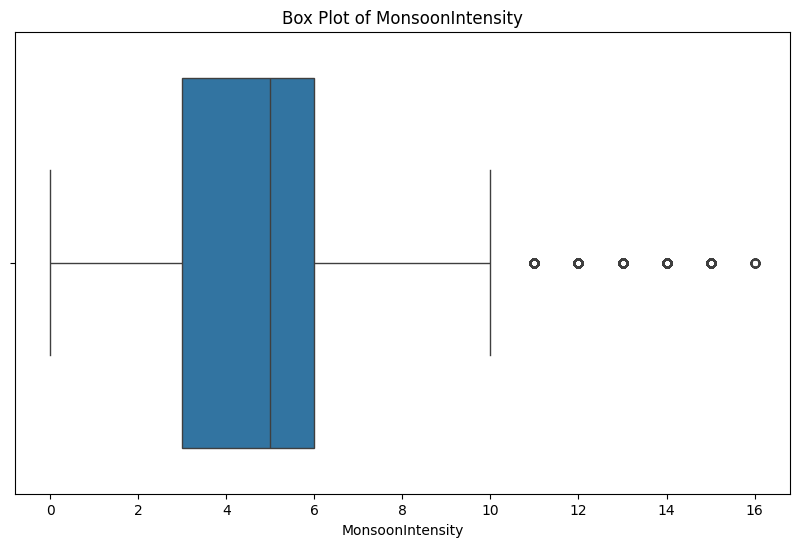

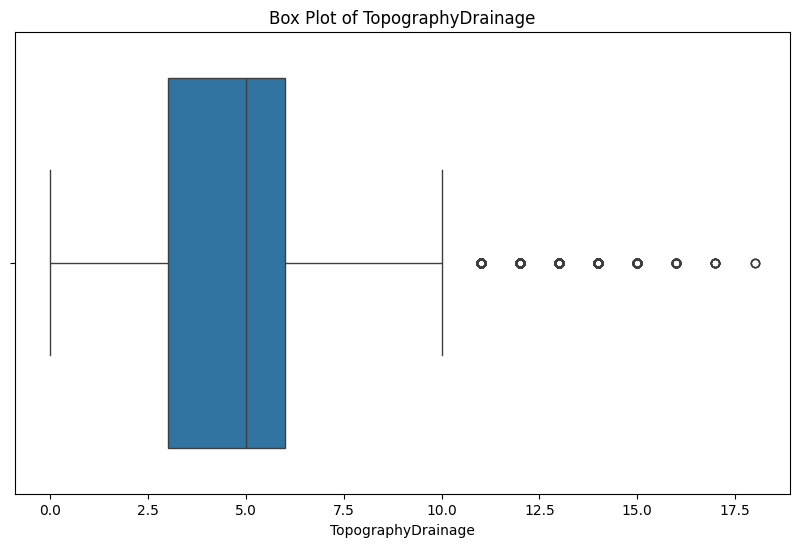

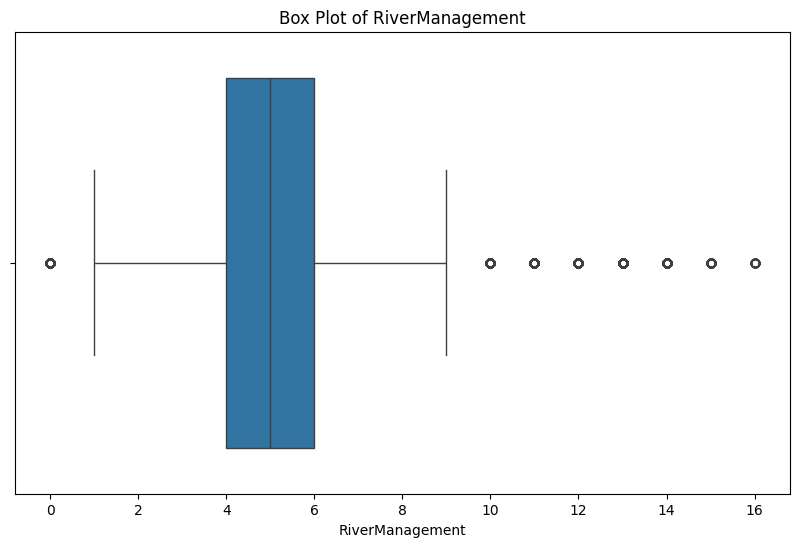

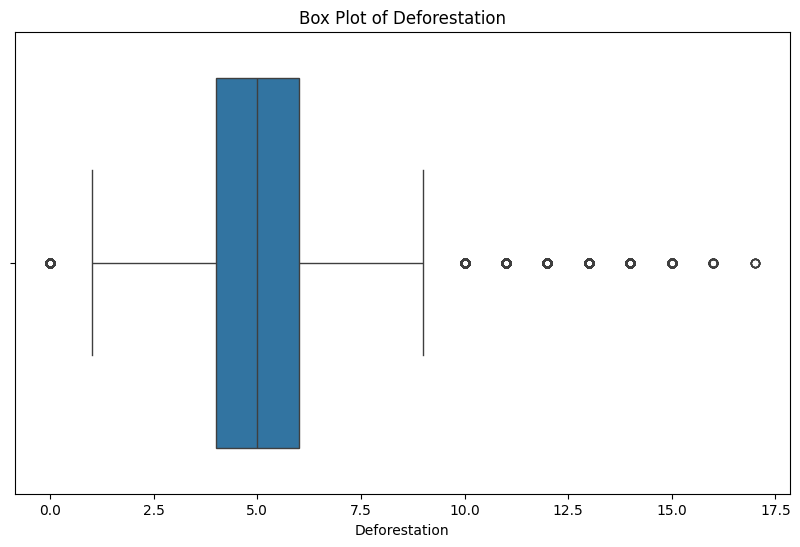

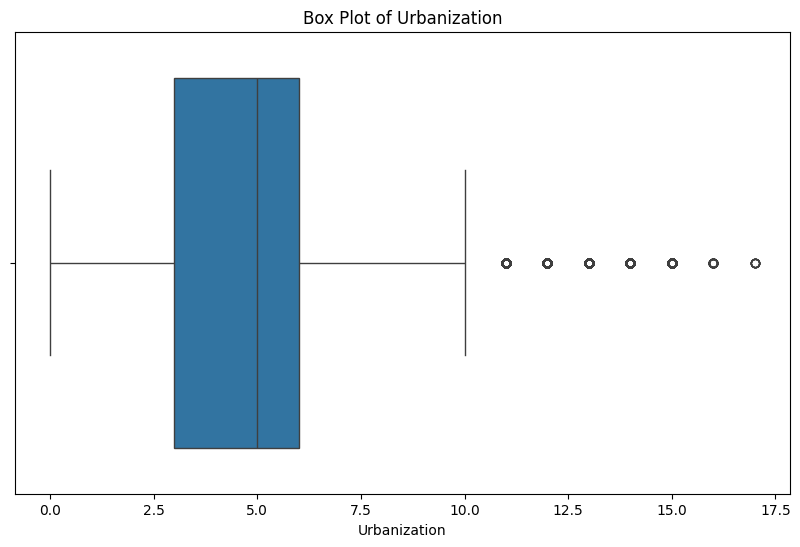

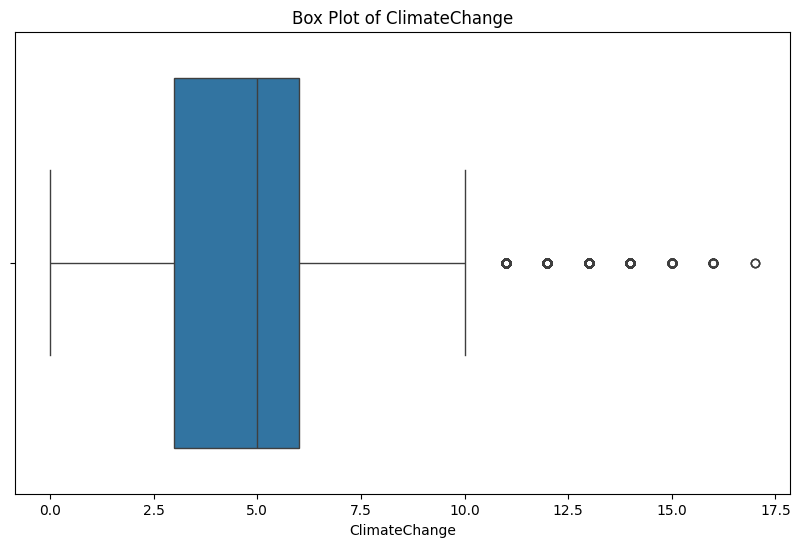

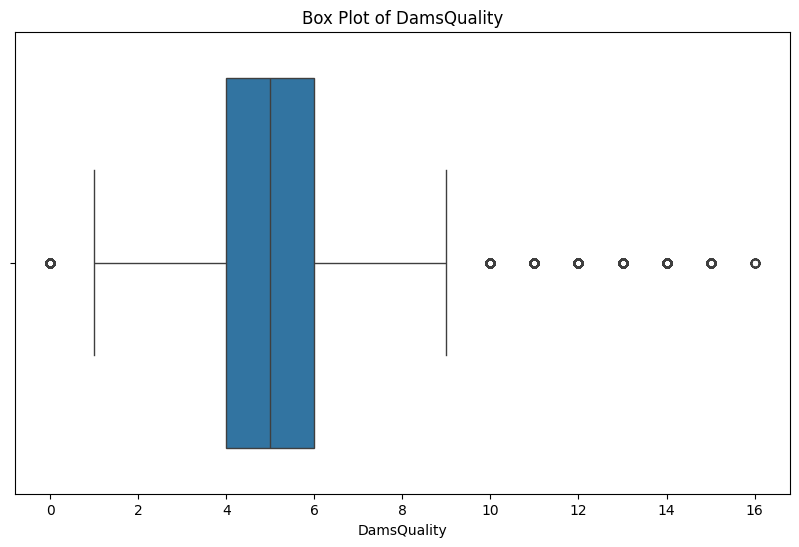

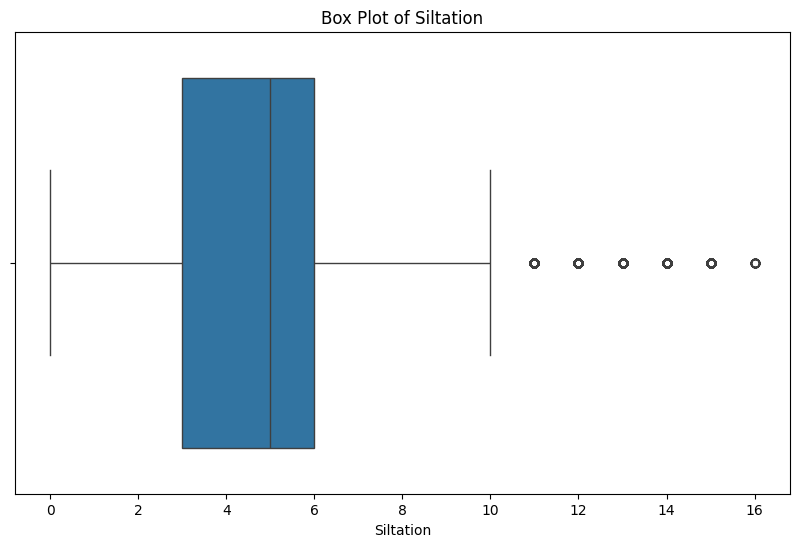

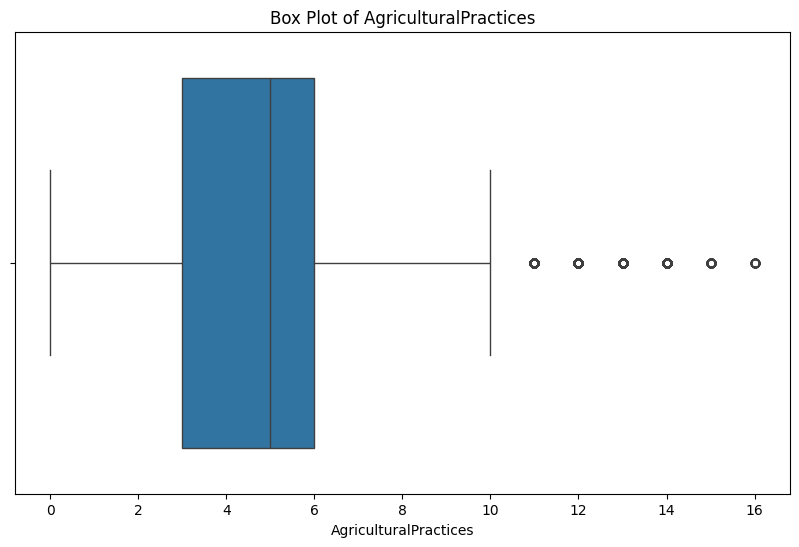

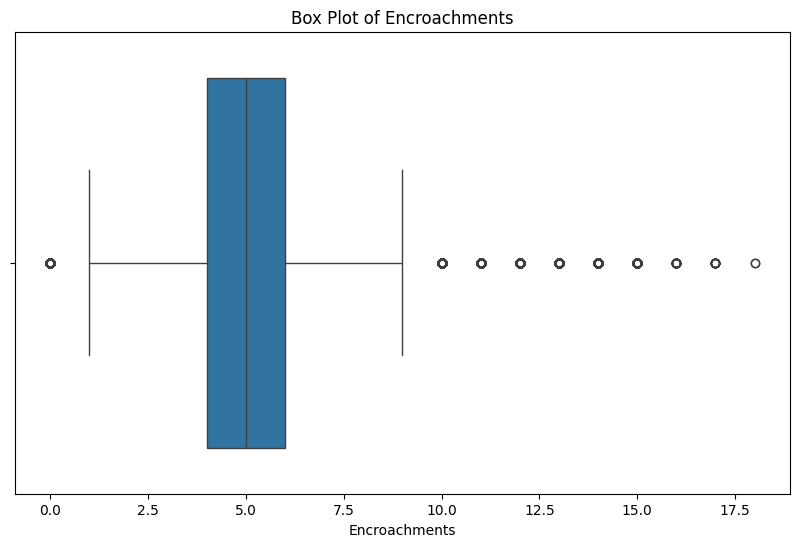

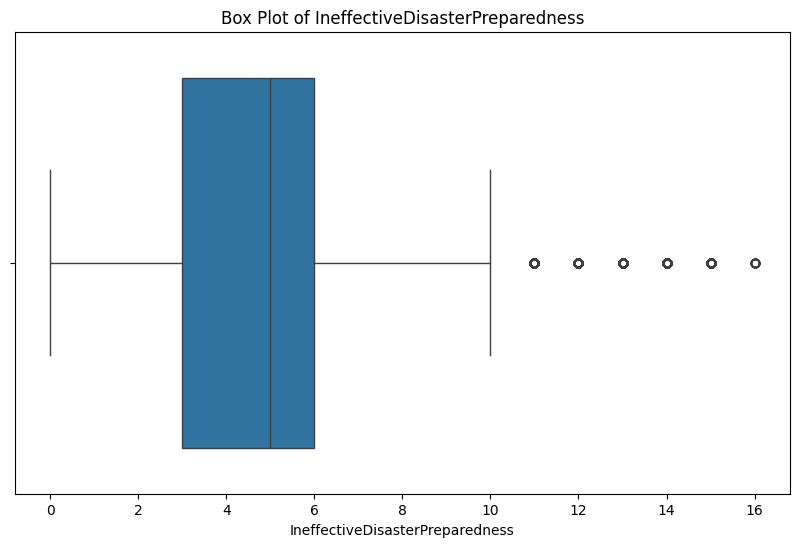

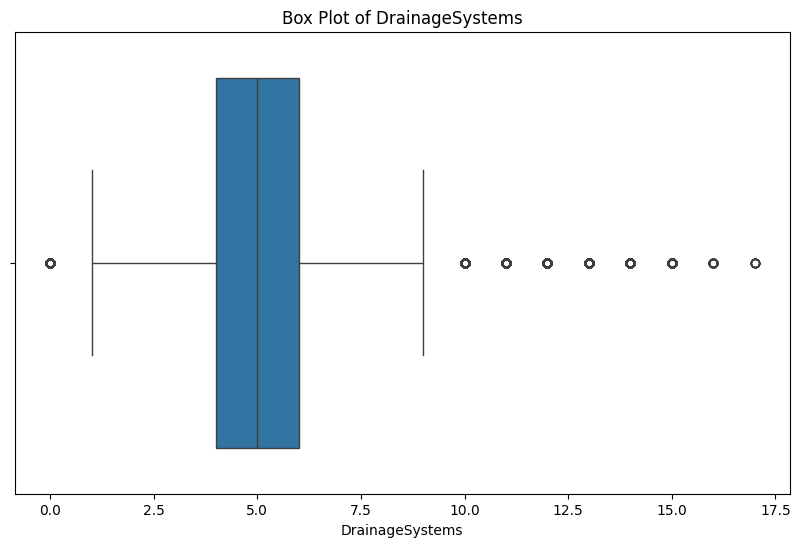

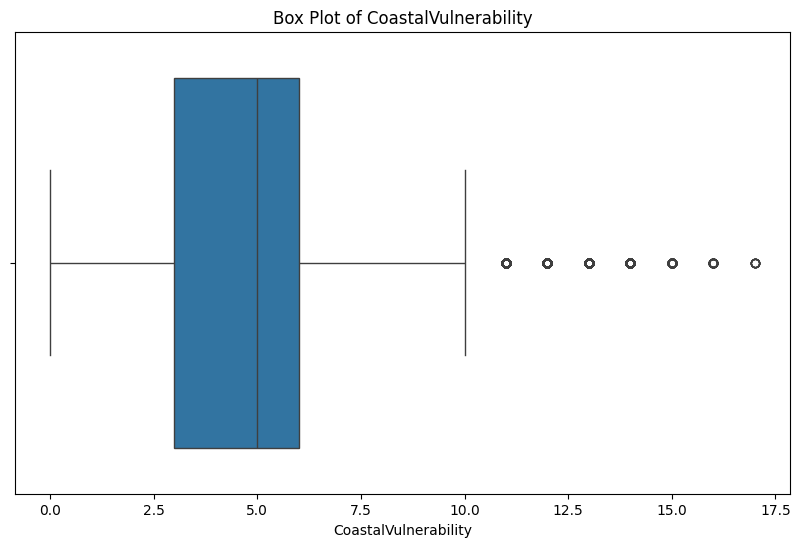

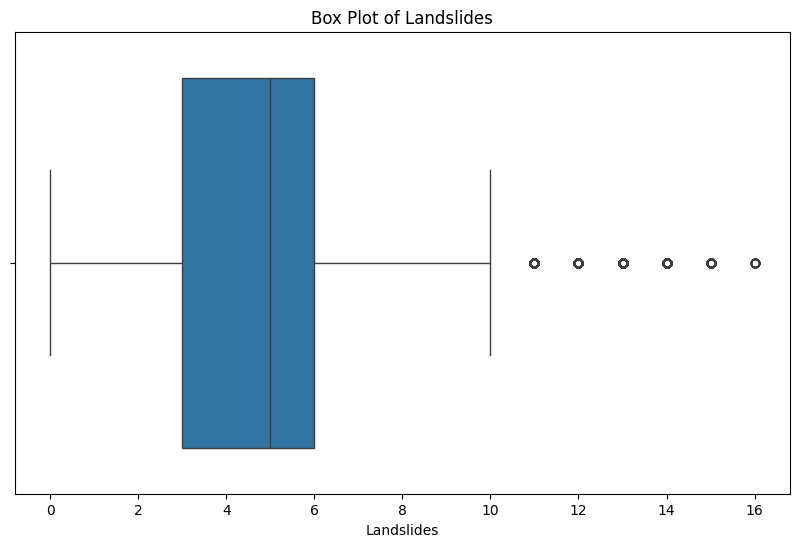

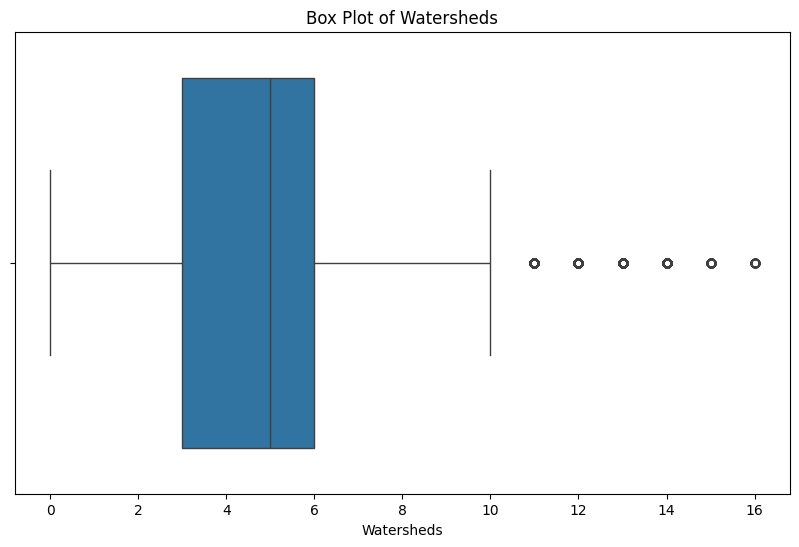

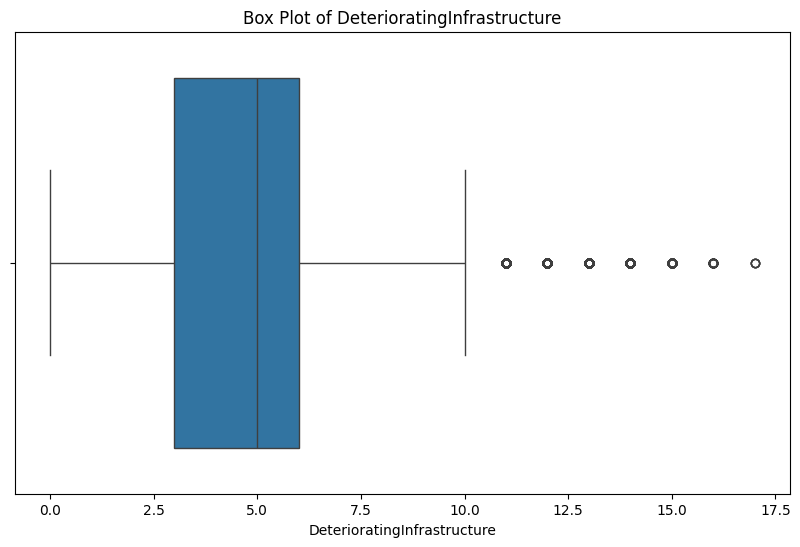

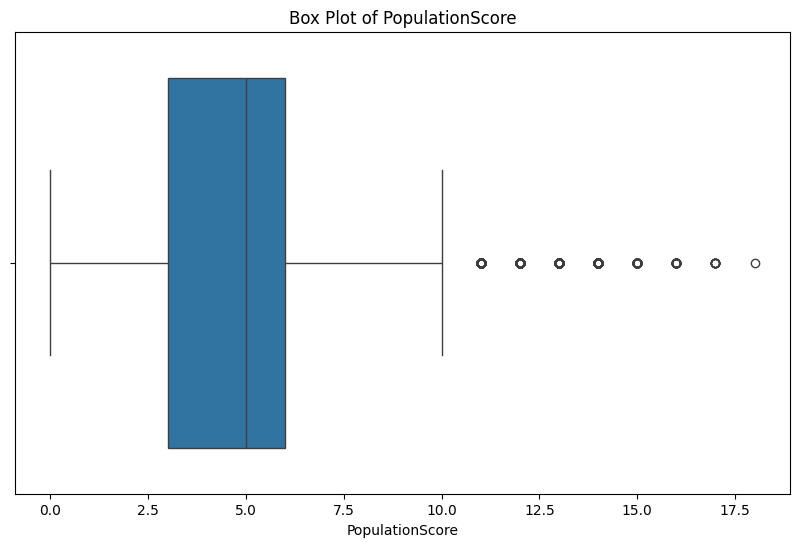

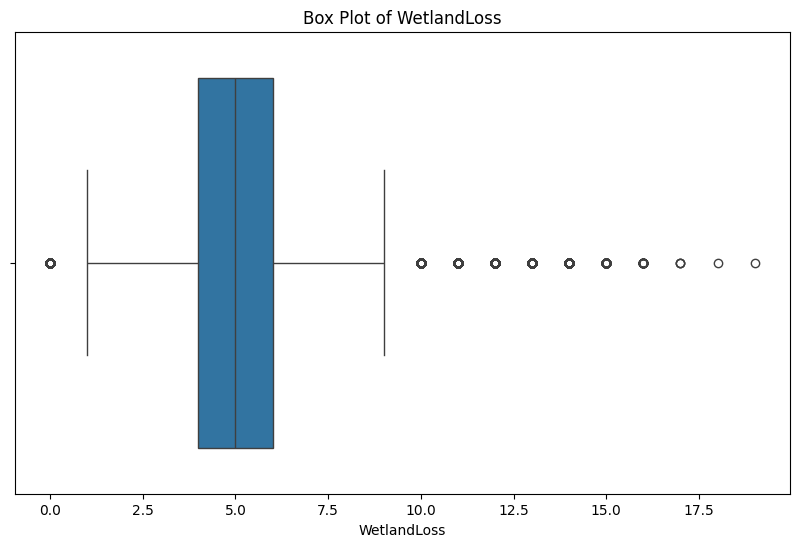

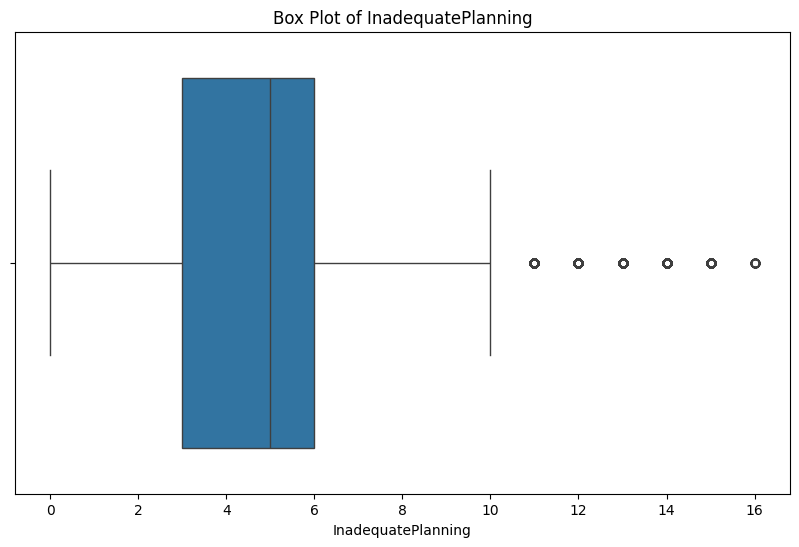

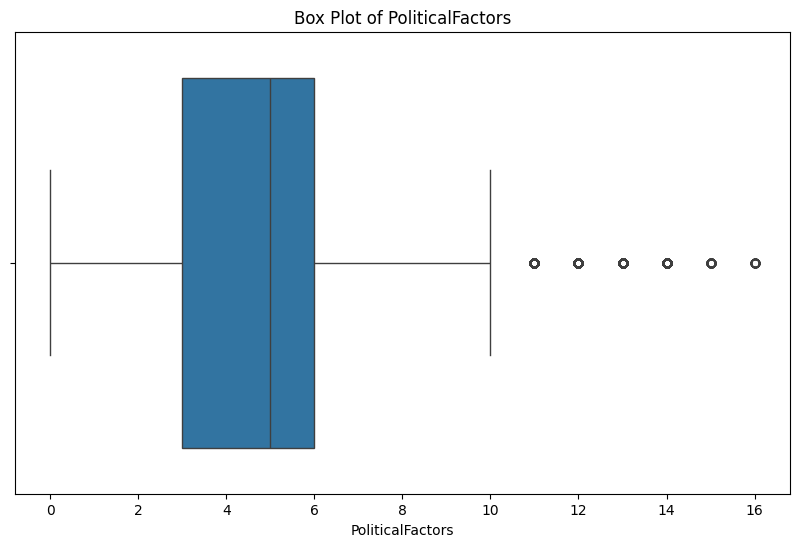

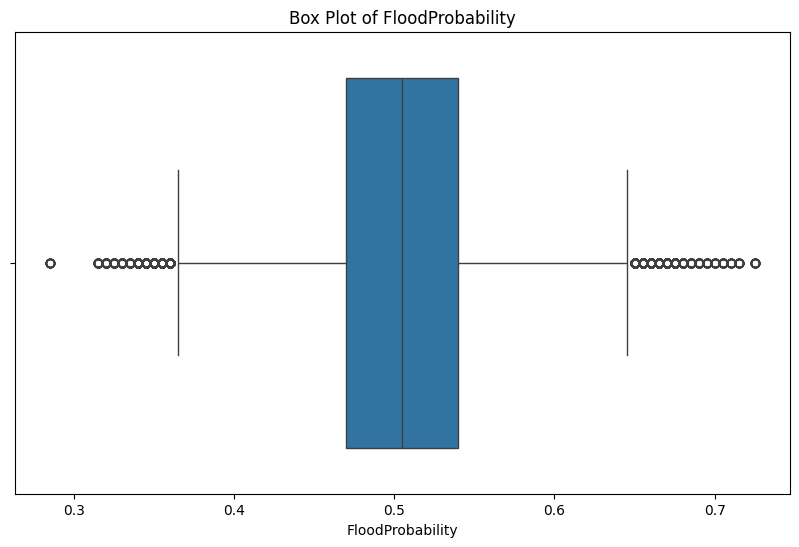

In [ ]:
#melakukan pengeekan data outler
import seaborn as sns
import matplotlib.pyplot as plt
 
for feature in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

karena pada box plot terlihat terdapat beberapa outler sehingga kita perlu melakukan penganganan outler dengan metode IQR yaitu metode yang mengganti data outler dengan batas atas dan bawah 

In [21]:
#menggantikan nilai yang outlier dengan nilai batas atas dan batas bawah
for feature in df.columns:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[feature] = df[feature].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

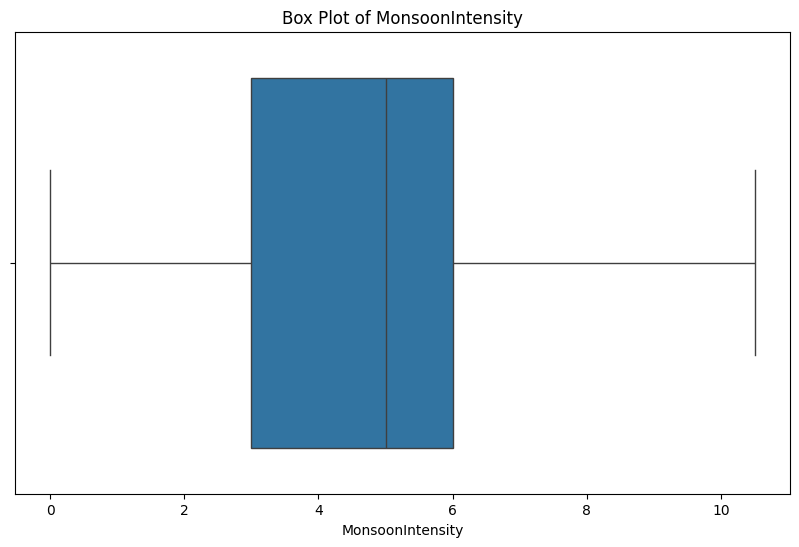

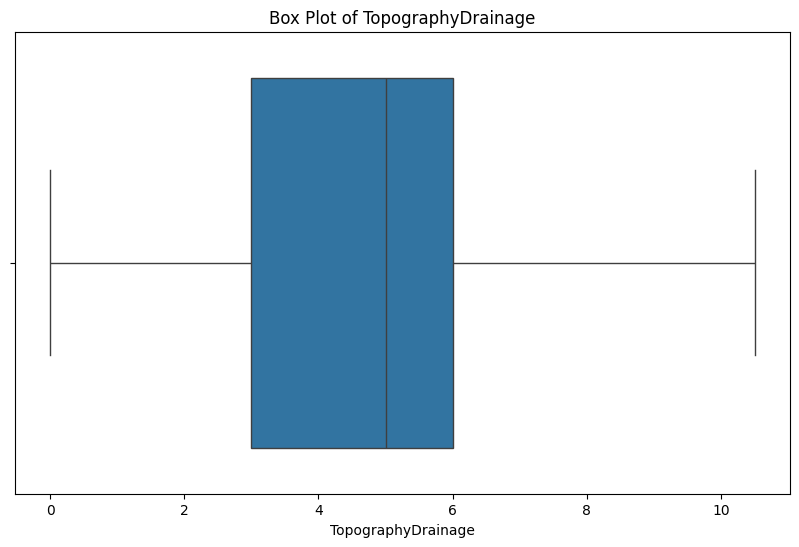

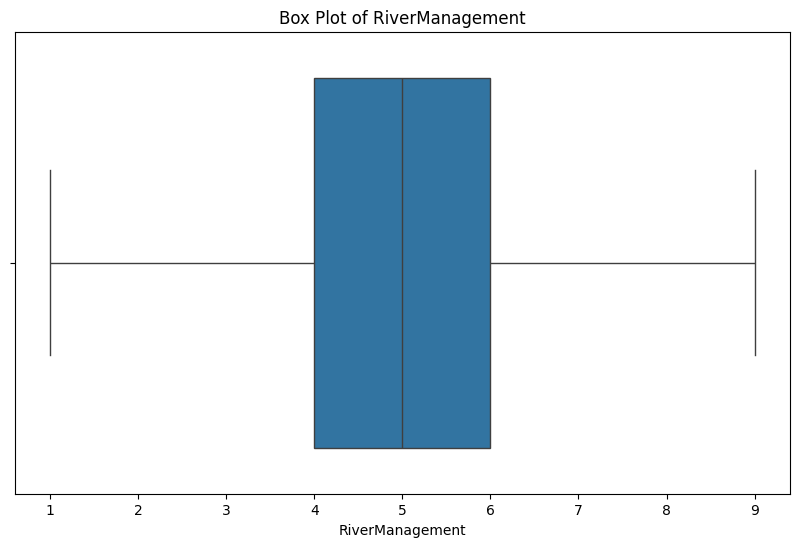

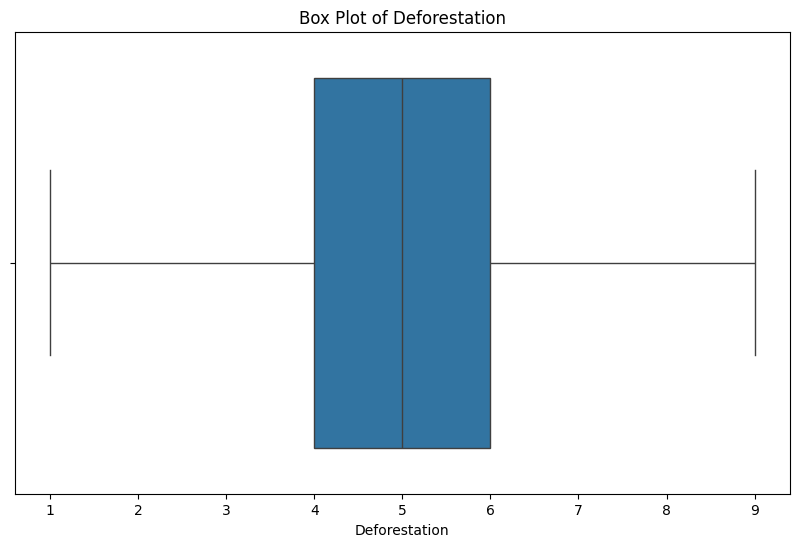

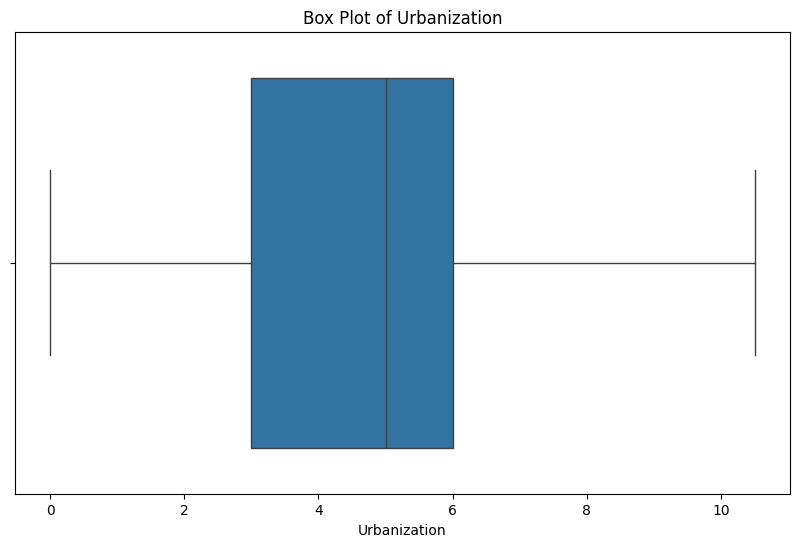

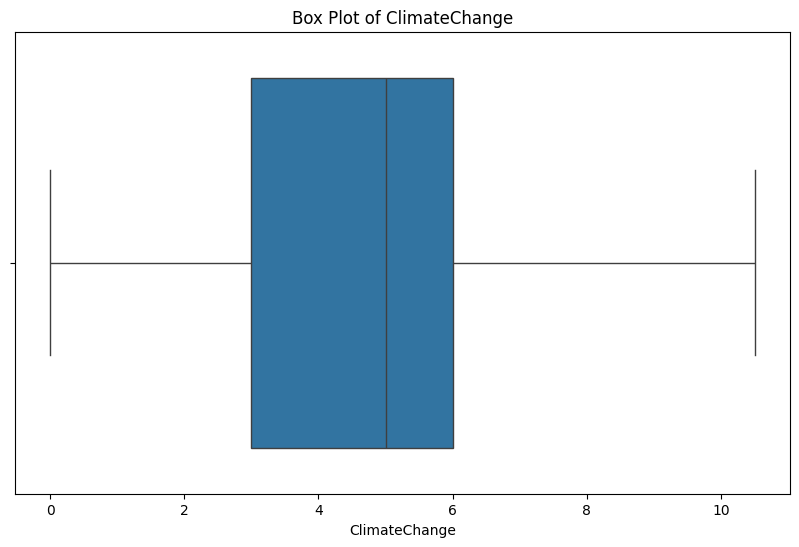

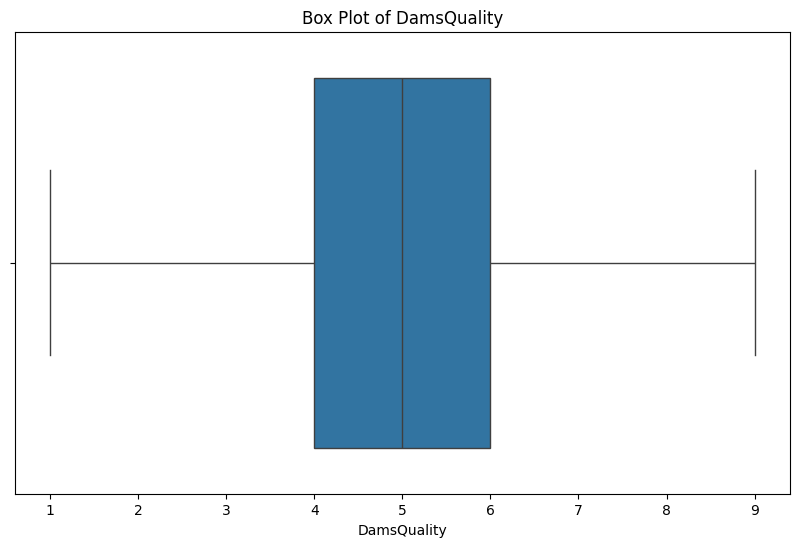

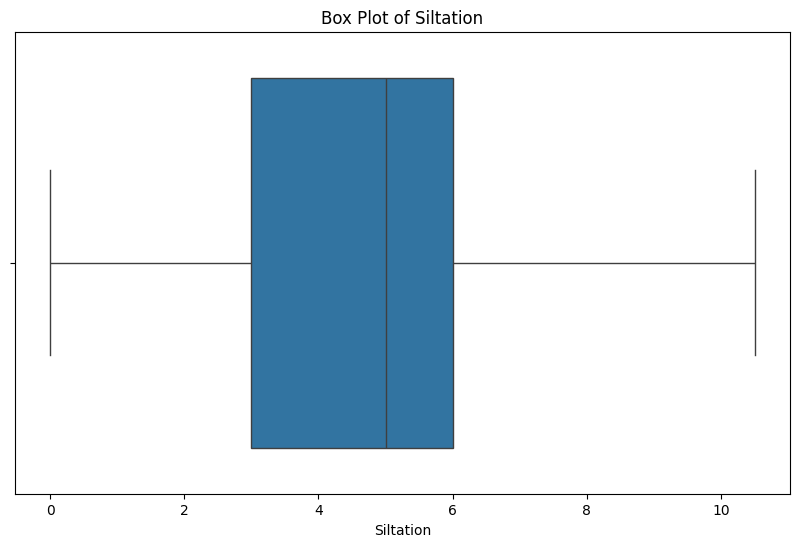

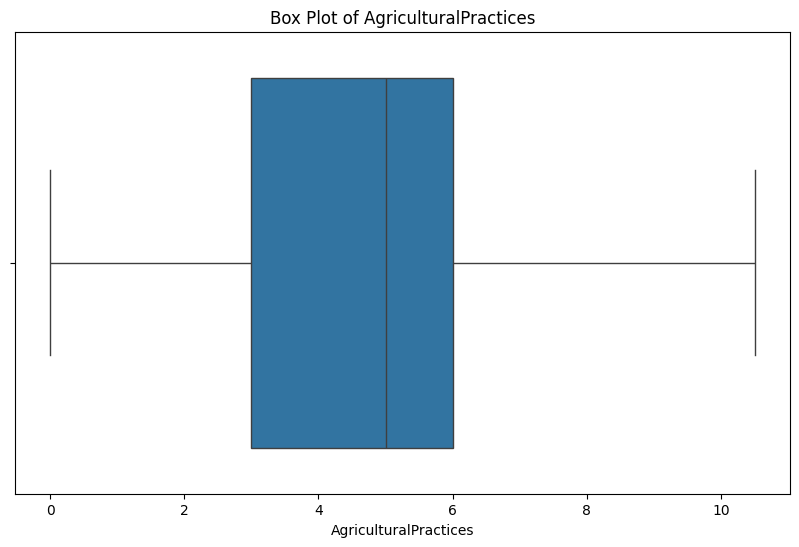

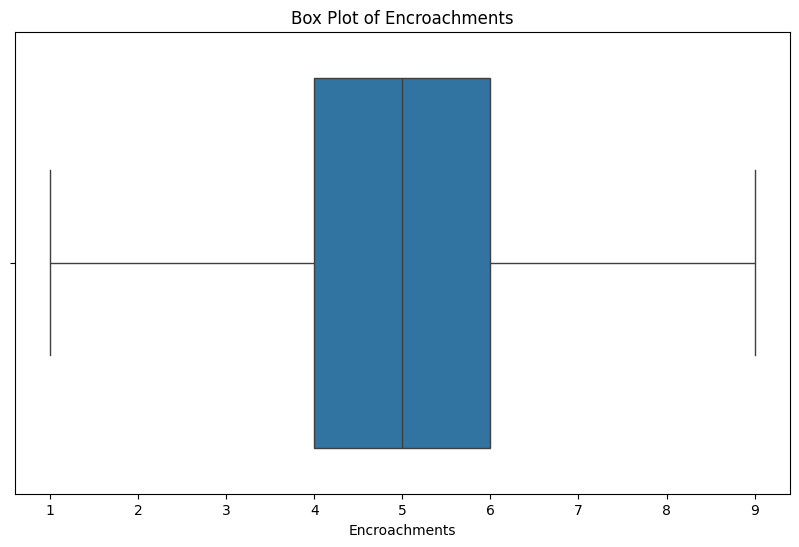

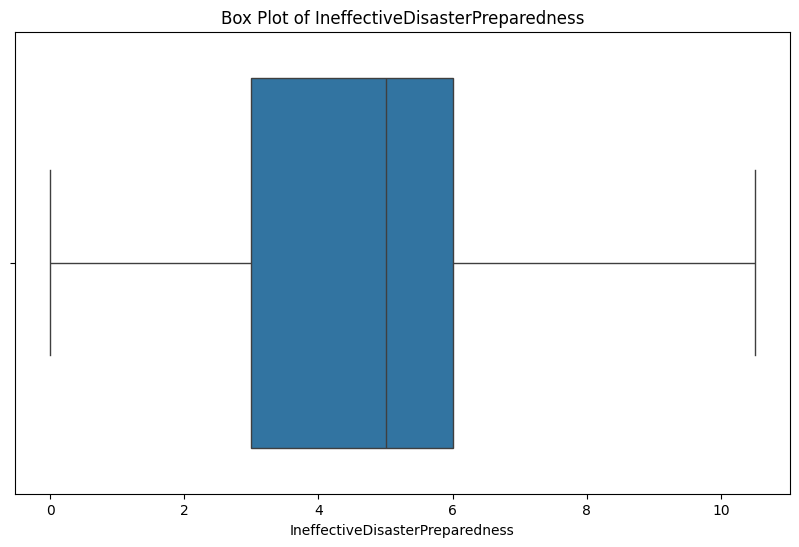

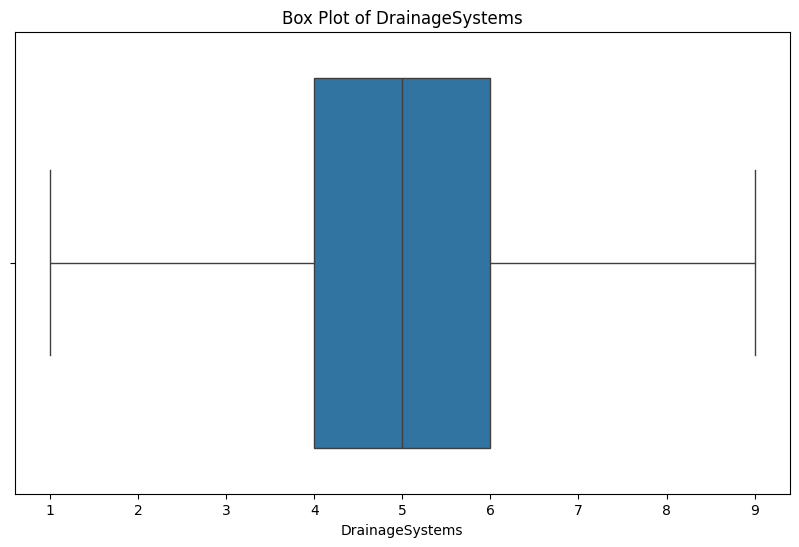

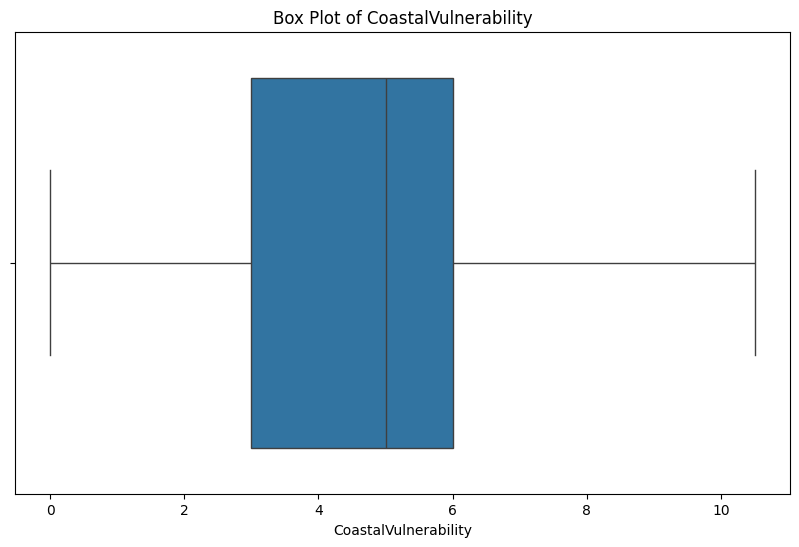

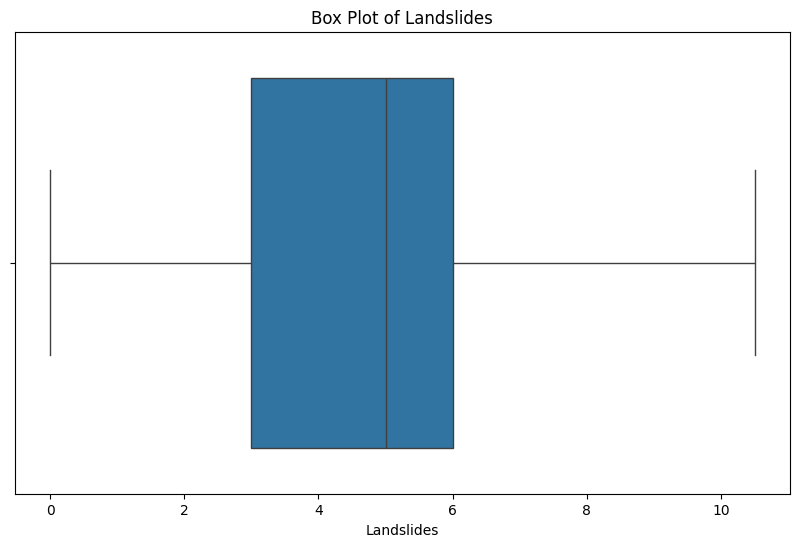

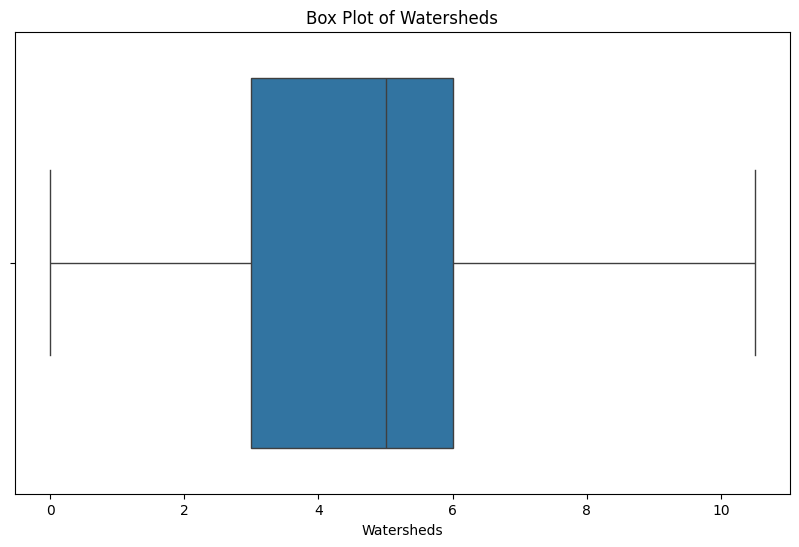

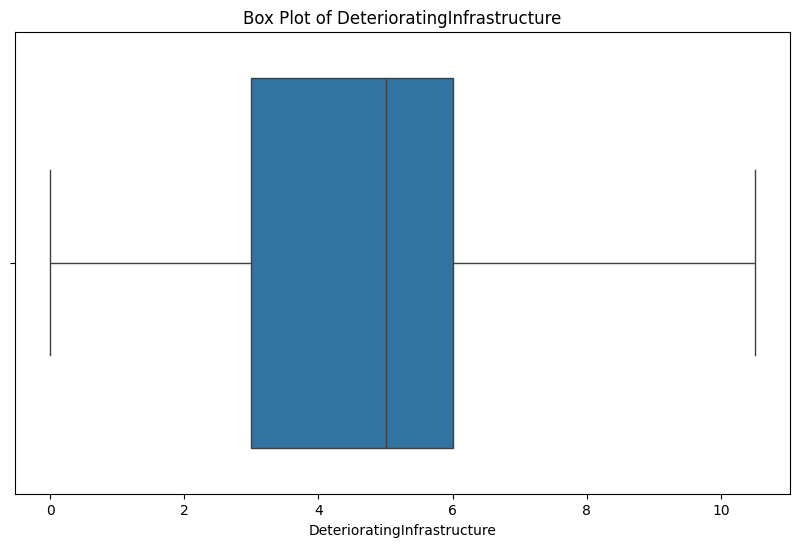

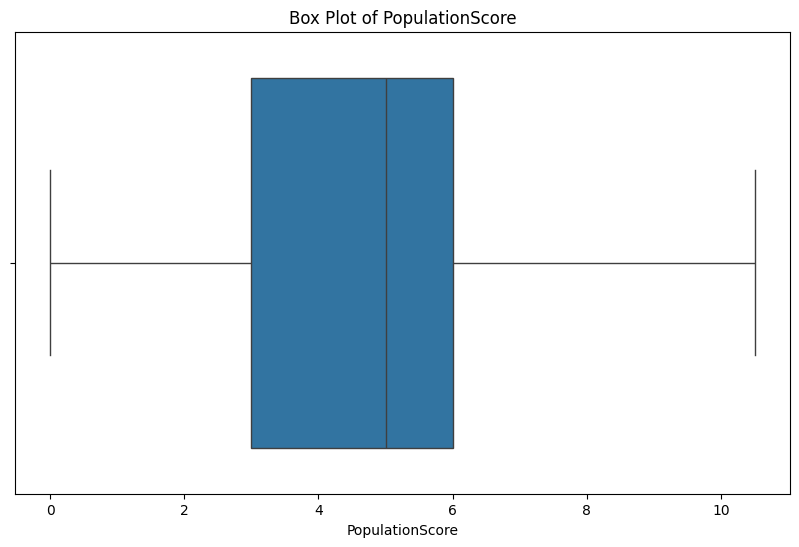

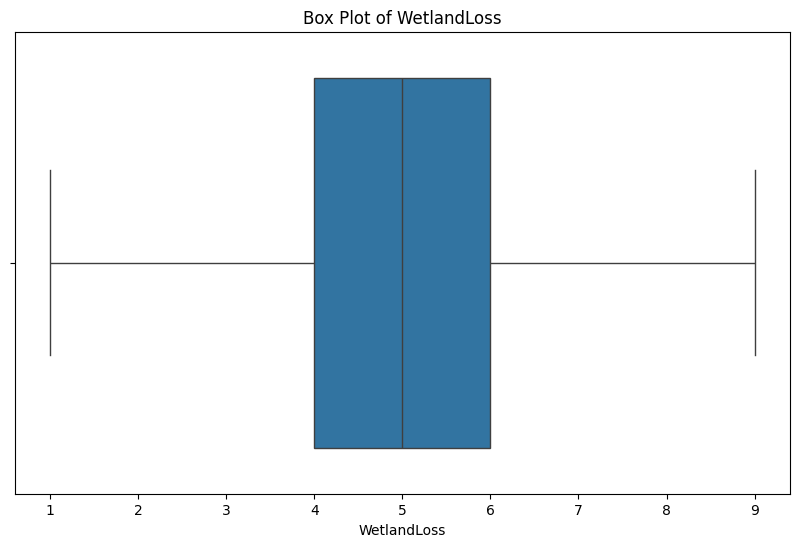

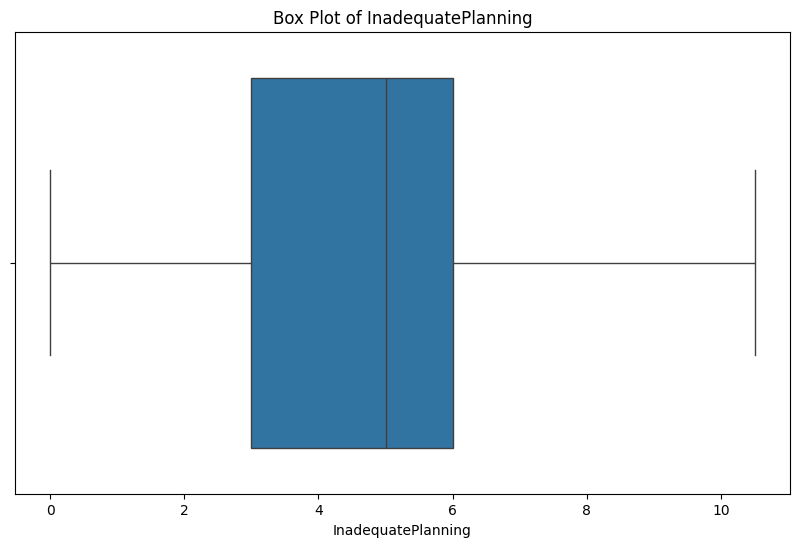

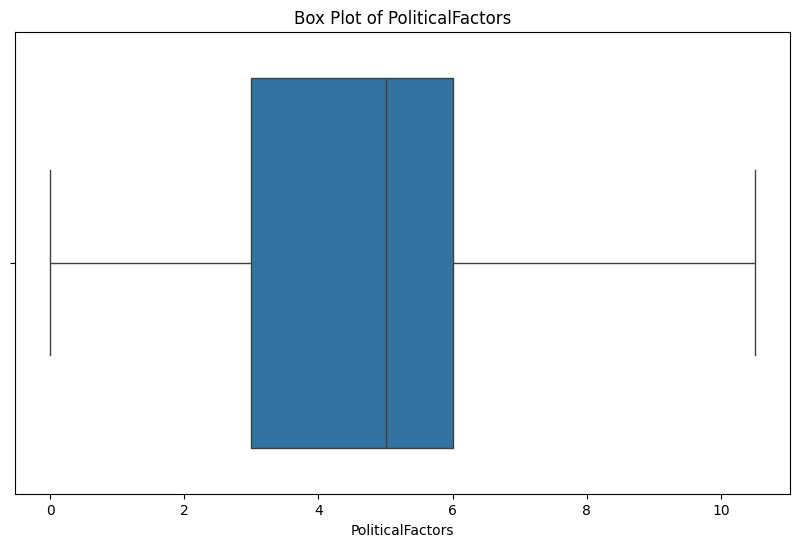

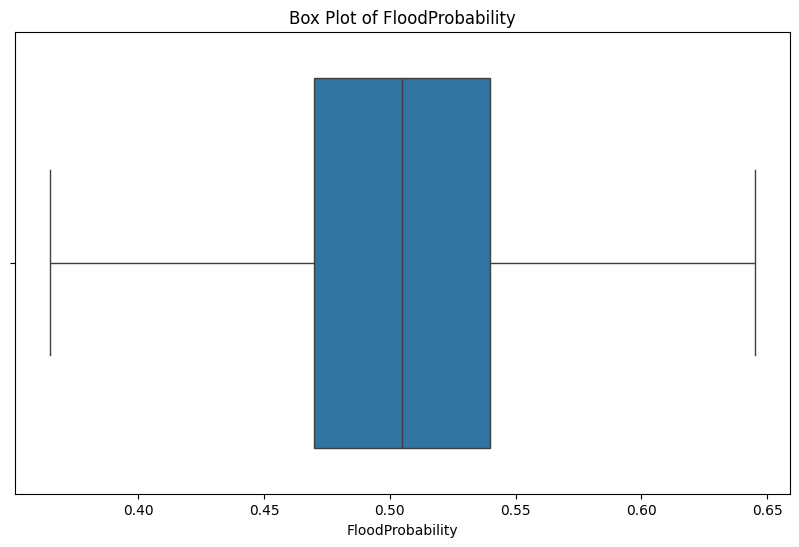

In [22]:
#pengecekan outler kedua kalinya
import seaborn as sns
import matplotlib.pyplot as plt
 
for feature in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

## EDA(EXPLORATORY DATA ANALYSIS)
### Dilakukan untuk melihat hubungan antar fitur dan target

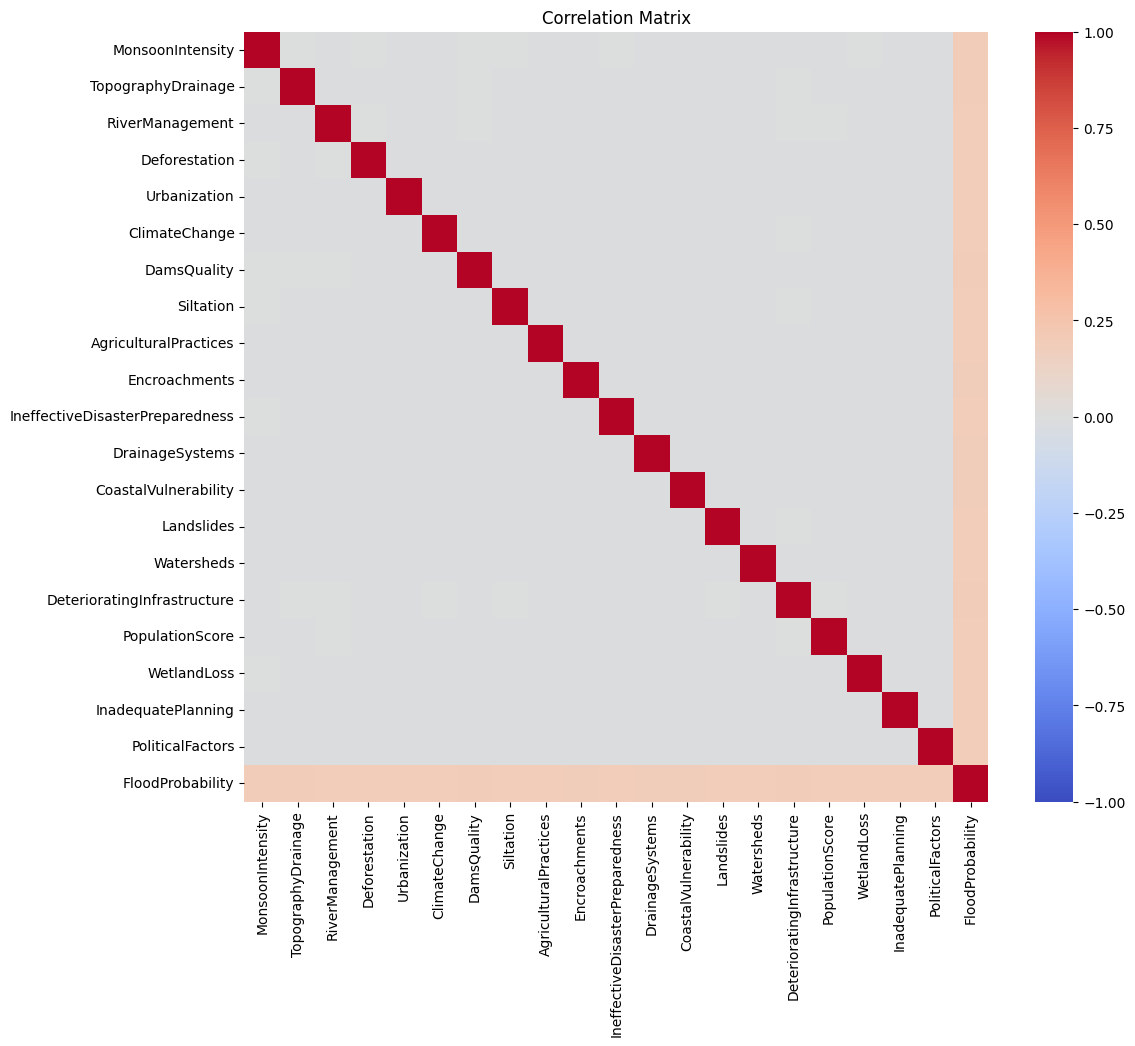

In [24]:
# Visualisasi korelasi antar variabel numerik dengan menggunakan matriks korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

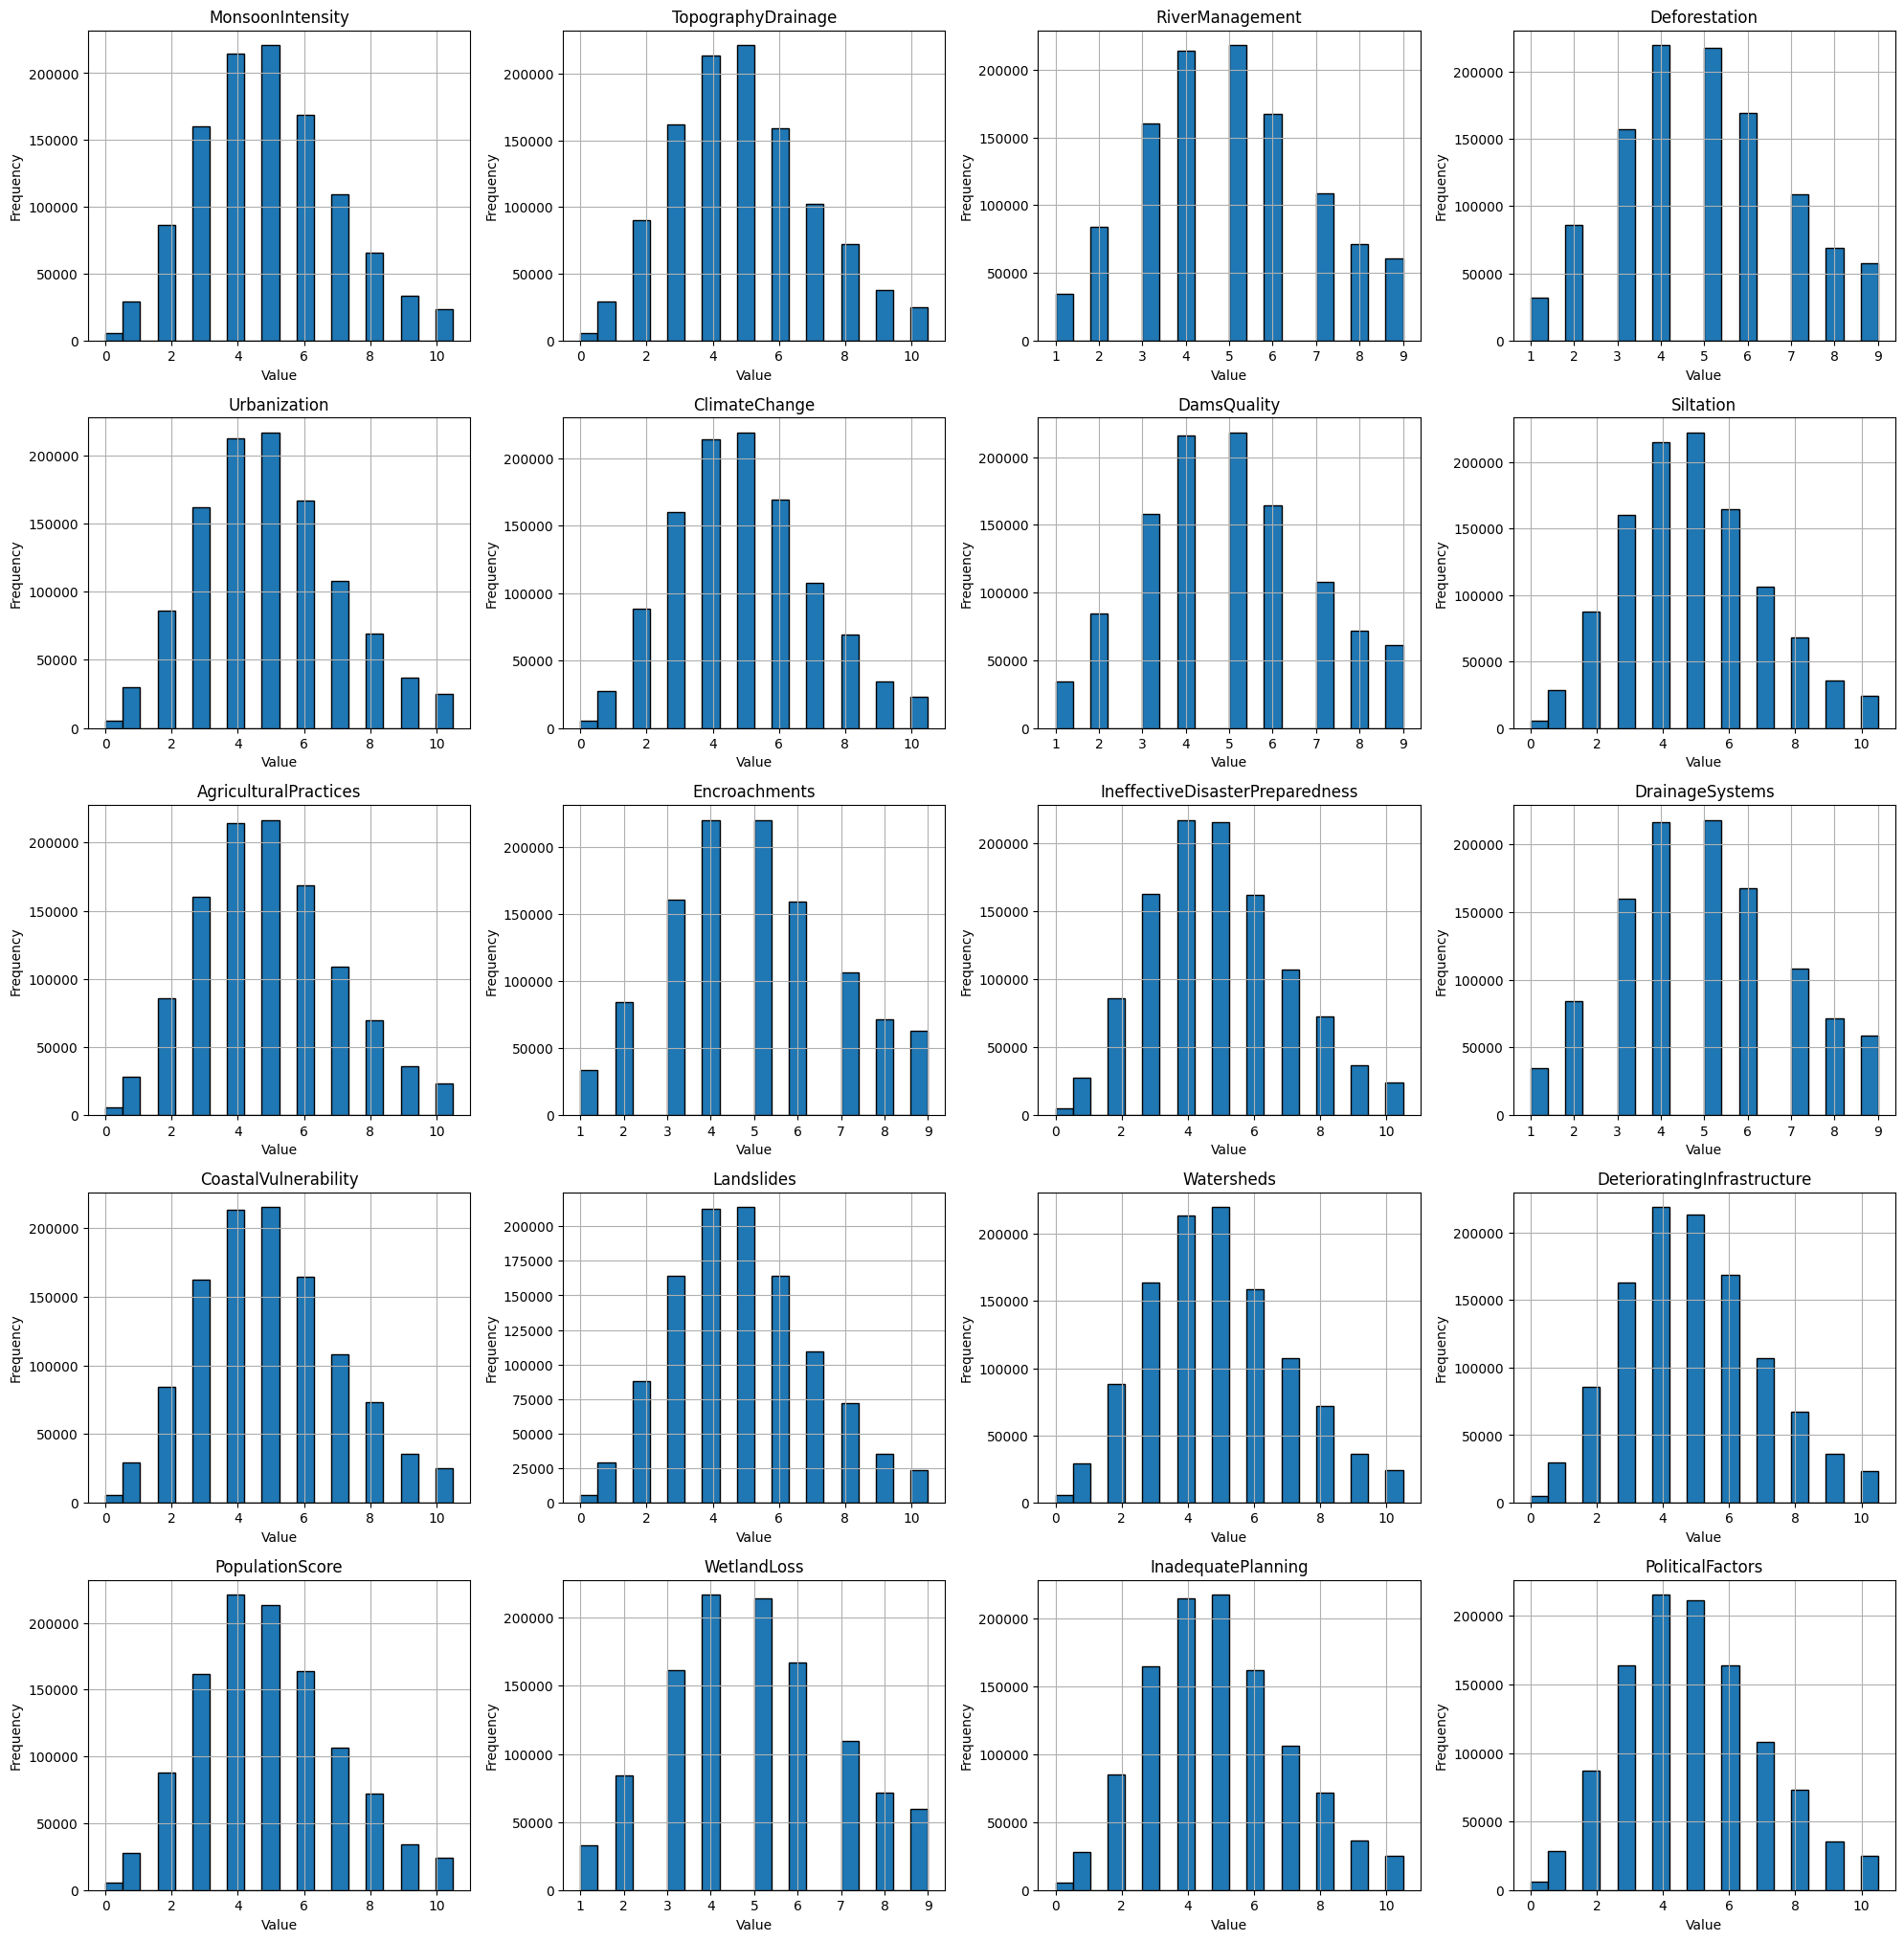

In [26]:
# Menghitung jumlah variabel
num_vars = df.shape[1]
 
# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4  # Jumlah kolom yang diinginkan
n_rows = -(-num_vars // n_cols)  # Ceiling division untuk menentukan jumlah baris
 
# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
 
# Flatten axes array untuk memudahkan iterasi jika diperlukan
axes = axes.flatten()
 
# Plot setiap variabel
for i, column in enumerate(df.columns[:20]):  # Membatasi hanya pada 20 variabel pertama untuk visualisasi
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

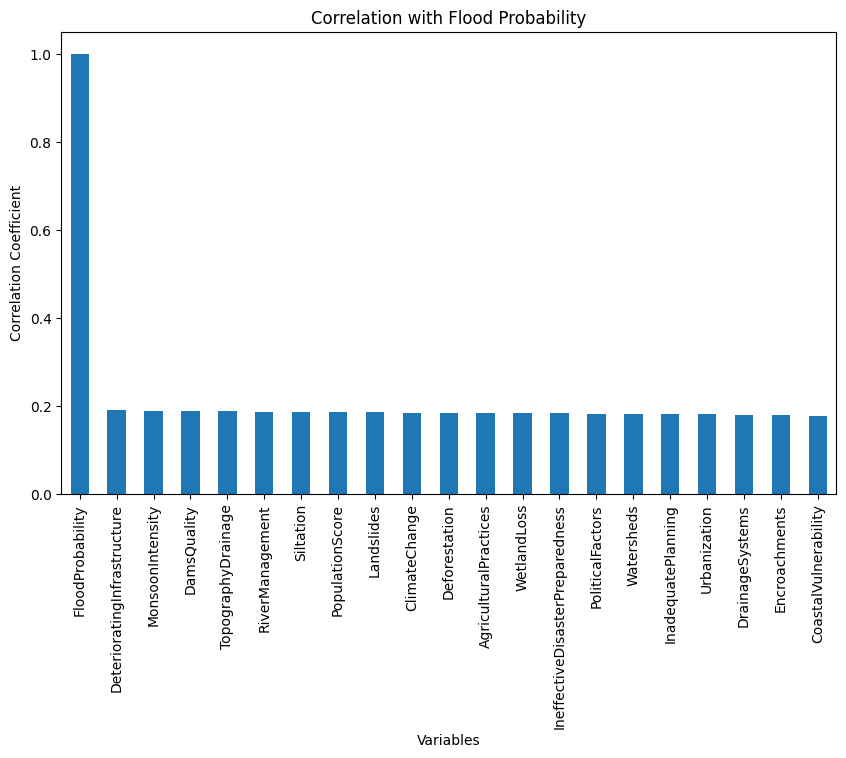

In [30]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df.corr()['FloodProbability']
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False).head(21)  # Menampilkan 20 variabel dengan korelasi tertinggi (beserta target)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with Flood Probability')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

#### Dari hasil diagram di atas disimpulkan bahwa setiap fitur memiliki hubungan dengan target (Flood Probability)

## Training Data

In [33]:
#melakukan spliting data
from sklearn.model_selection import train_test_split
X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
#setalah melakukan spliting data, kita akan melakukan normalisasi data dengan menggunakan StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#melakukan training model dengan menggunakan beberapa algoritma regresi, seperti Linear Regression, Gradient Boosting Regressor, dan Lars (Least Angle Regression).
# Lars (Least Angle Regression)
from sklearn import linear_model
# Gunakan X_train_scaled, bukan X_train
lars = linear_model.Lars(n_nonzero_coefs=1).fit(X_train_scaled, y_train)
 
# 2. Linear Regression
from sklearn.linear_model import LinearRegression
LR = LinearRegression().fit(X_train_scaled, y_train)
 
# 3. Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
GBR = GradientBoostingRegressor(random_state=184)
GBR.fit(X_train_scaled, y_train)

print("Semua model berhasil dilatih menggunakan data terskala!")


Semua model berhasil dilatih menggunakan data terskala!


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Lakukan Prediksi (Pastikan menggunakan X_test_scaled!)
pred_lars = lars.predict(X_test_scaled)
pred_lr = LR.predict(X_test_scaled)
pred_gbr = GBR.predict(X_test_scaled)

# 2. Hitung Metrik untuk masing-masing model
models = {
    'Lars': pred_lars,
    'Linear Regression': pred_lr,
    'Gradient Boosting': pred_gbr
}

results = []

for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse) # Tambahkan RMSE karena satuannya sama dengan harga asli
    r2 = r2_score(y_test, pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

# 3. Tampilkan dalam satu DataFrame
df_results = pd.DataFrame(results).set_index('Model')
df_results

,MAE,MSE,RMSE,R2 Score
Model,,,,
Lars,0.040803,0.002572,0.050712,0.000011
Linear Regression,0.016242,0.000420,0.020502,0.836564
Gradient Boosting,0.026022,0.000994,0.031531,0.613403


#### berdarsarkan hasil evaluasi model menggunakan 4 matriks evaluasi di simpulkan bahwa linear regression merupakan model dengan kinerja terbaik berdarsarkan data dengan nilai MAE terkecil (0,016242), nilai MSE terkecil (0,000420), nilai RMSE terkecil (0,020502),dan R2 score tertinggi(0,836564) yang berarti bahwa model memiliki data yang cukup linear

In [39]:
#menyimpan model yang sudah dilatih menggunakan joblib
import joblib

#Simpan Modelnya
joblib.dump(LR, 'model_lr_final.joblib')

#Simpan Preprocessor-nya (Hanya untuk fitur X)
joblib.dump(scaler, 'scaler.joblib')


['scaler.joblib']